# 📊 EDA — HAM10000 Skin Lesion Dataset

**Mục tiêu:**
- Khám phá phân phối dữ liệu và class imbalance
- Visualize sample ảnh từng class
- Phân tích metadata: tuổi, giới tính, vị trí tổn thương
- Kiểm tra data leakage qua lesion_id
- Tính class weights cho training

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from collections import Counter

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'text.color':       '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

DATA_DIR = '../data'  # Điều chỉnh nếu cần
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Inspect Metadata

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'HAM10000_metadata.csv'))

CLASS_NAMES = ['akiec','bcc','bkl','df','mel','nv','vasc']
CLASS_FULL = {
    'akiec': 'Actinic Keratoses',
    'bcc':   'Basal Cell Carcinoma',
    'bkl':   'Benign Keratosis',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Melanocytic Nevi',
    'vasc':  'Vascular Lesions',
}
LABEL_MAP = {n: i for i, n in enumerate(CLASS_NAMES)}

df['label'] = df['dx'].map(LABEL_MAP)

print(f'Total images   : {len(df):,}')
#print(f'Unique patients: {df["lesion_id"].nunique():,}')
print(f'Columns        : {list(df.columns)}')
df.head()

Total images   : 10,015
Columns        : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label']


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2


In [3]:
print('=== Missing values ===')
print(df.isnull().sum())
print()
print('=== dx_type (ground truth method) ===')
print(df['dx_type'].value_counts())
print()
print('=== Class distribution ===')
vc = df['dx'].value_counts()
for cls in CLASS_NAMES:
    cnt = vc.get(cls, 0)
    pct = cnt/len(df)*100
    bar = '█' * int(pct/2)
    print(f'  {cls:>6}  {cnt:>5}  ({pct:5.1f}%)  {bar}')

=== Missing values ===
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
label            0
dtype: int64

=== dx_type (ground truth method) ===
dx_type
histo        5340
follow_up    3704
consensus     902
confocal       69
Name: count, dtype: int64

=== Class distribution ===
   akiec    327  (  3.3%)  █
     bcc    514  (  5.1%)  ██
     bkl   1099  ( 11.0%)  █████
      df    115  (  1.1%)  
     mel   1113  ( 11.1%)  █████
      nv   6705  ( 66.9%)  █████████████████████████████████
    vasc    142  (  1.4%)  


## 2. Class Distribution — Imbalance Analysis

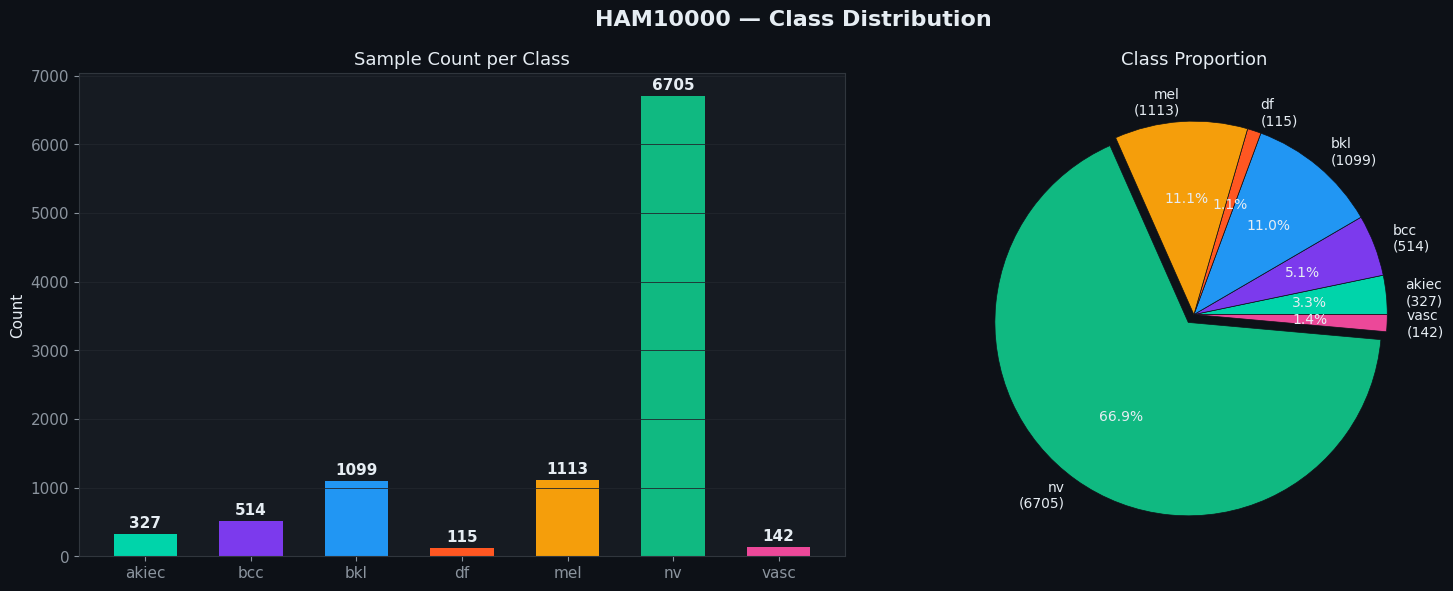


Imbalance ratio (max/min): 58.3x
→ Class weights needed for training!


In [4]:
counts = [df[df['dx']==c].shape[0] for c in CLASS_NAMES]
COLORS = ['#00d4aa','#7c3aed','#2196F3','#FF5722','#f59e0b','#10b981','#ec4899']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('HAM10000 — Class Distribution', fontsize=16, fontweight='bold', color='#e6edf3')

# Bar chart
bars = axes[0].bar(CLASS_NAMES, counts, color=COLORS, edgecolor='none', width=0.6)
axes[0].set_title('Sample Count per Class', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].grid(axis='y')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
explode = [0.05 if c=='nv' else 0 for c in CLASS_NAMES]
axes[1].pie(counts, labels=[f'{c}\n({cnt})' for c,cnt in zip(CLASS_NAMES, counts)],
            colors=COLORS, autopct='%1.1f%%', explode=explode,
            textprops={'color': '#e6edf3', 'fontsize': 10},
            wedgeprops={'linewidth': 0.5, 'edgecolor': '#0d1117'})
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()
plt.savefig('../data/eda_class_distribution.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

imbalance_ratio = max(counts) / min(counts)
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.1f}x')
print('→ Class weights needed for training!')

## 3. Sample Images per Class

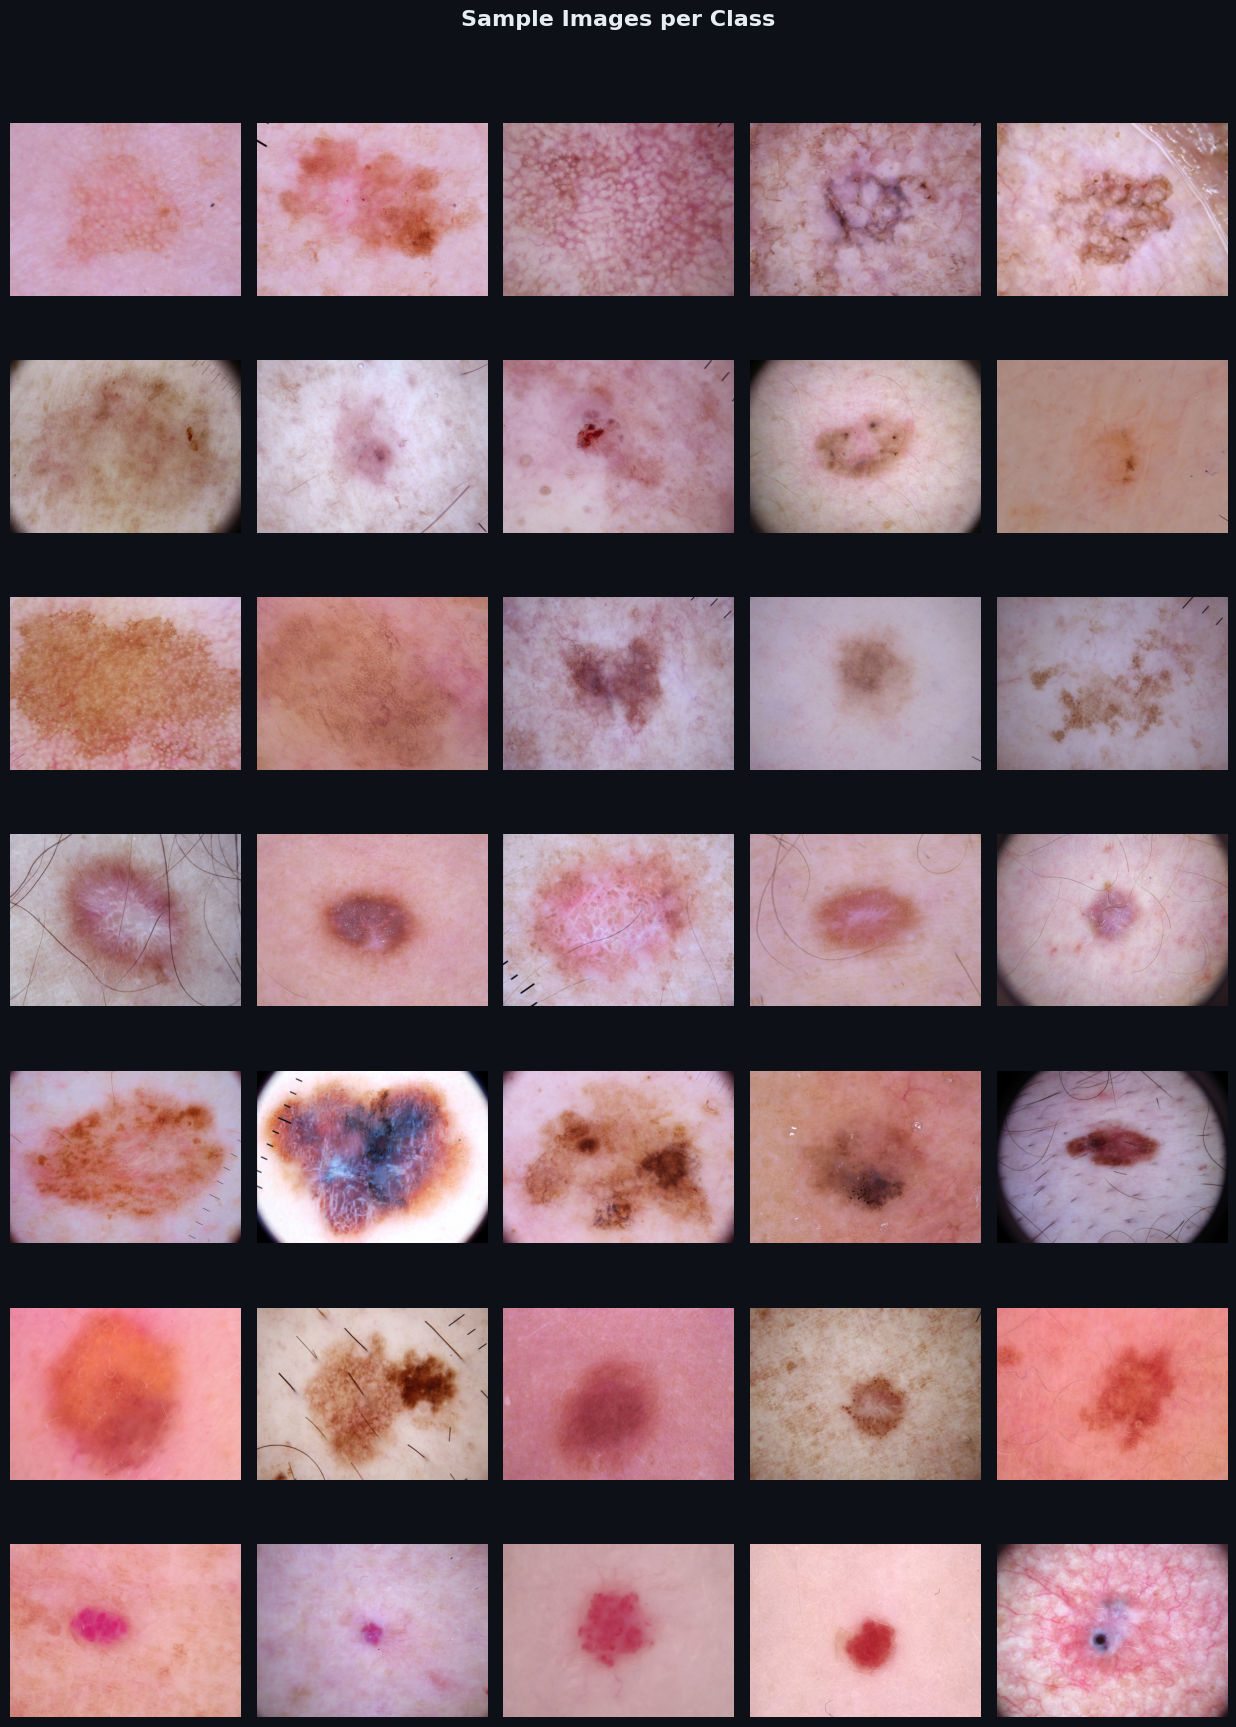

In [5]:
def find_image(image_id, data_dir):
    for part in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
        p = os.path.join(data_dir, part, f'{image_id}.jpg')
        if os.path.exists(p):
            return p
    return None

N_SAMPLES = 5
fig, axes = plt.subplots(len(CLASS_NAMES), N_SAMPLES,
                          figsize=(N_SAMPLES*2.5, len(CLASS_NAMES)*2.5))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold',
             color='#e6edf3', y=1.01)

for row_idx, cls in enumerate(CLASS_NAMES):
    subset = df[df['dx'] == cls].sample(n=min(N_SAMPLES, df[df['dx']==cls].shape[0]),
                                         random_state=42)
    for col_idx in range(N_SAMPLES):
        ax = axes[row_idx][col_idx]
        ax.axis('off')
        if col_idx < len(subset):
            img_path = find_image(subset.iloc[col_idx]['image_id'], DATA_DIR)
            if img_path:
                img = Image.open(img_path)
                ax.imshow(img)
                if col_idx == 0:
                    ax.set_ylabel(f'{cls.upper()}\n{CLASS_FULL[cls]}',
                                  fontsize=9, rotation=0, ha='right', va='center',
                                  labelpad=5, color=COLORS[row_idx])
                    ax.yaxis.set_label_coords(-0.02, 0.5)

plt.tight_layout()
plt.savefig('../data/eda_sample_images.png', dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 4. Metadata Analysis (Age, Sex, Localization)

C:\Users\hieu2\AppData\Local\Temp\ipykernel_5008\2116491494.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0][0].boxplot(age_data, labels=CLASS_NAMES, patch_artist=True,


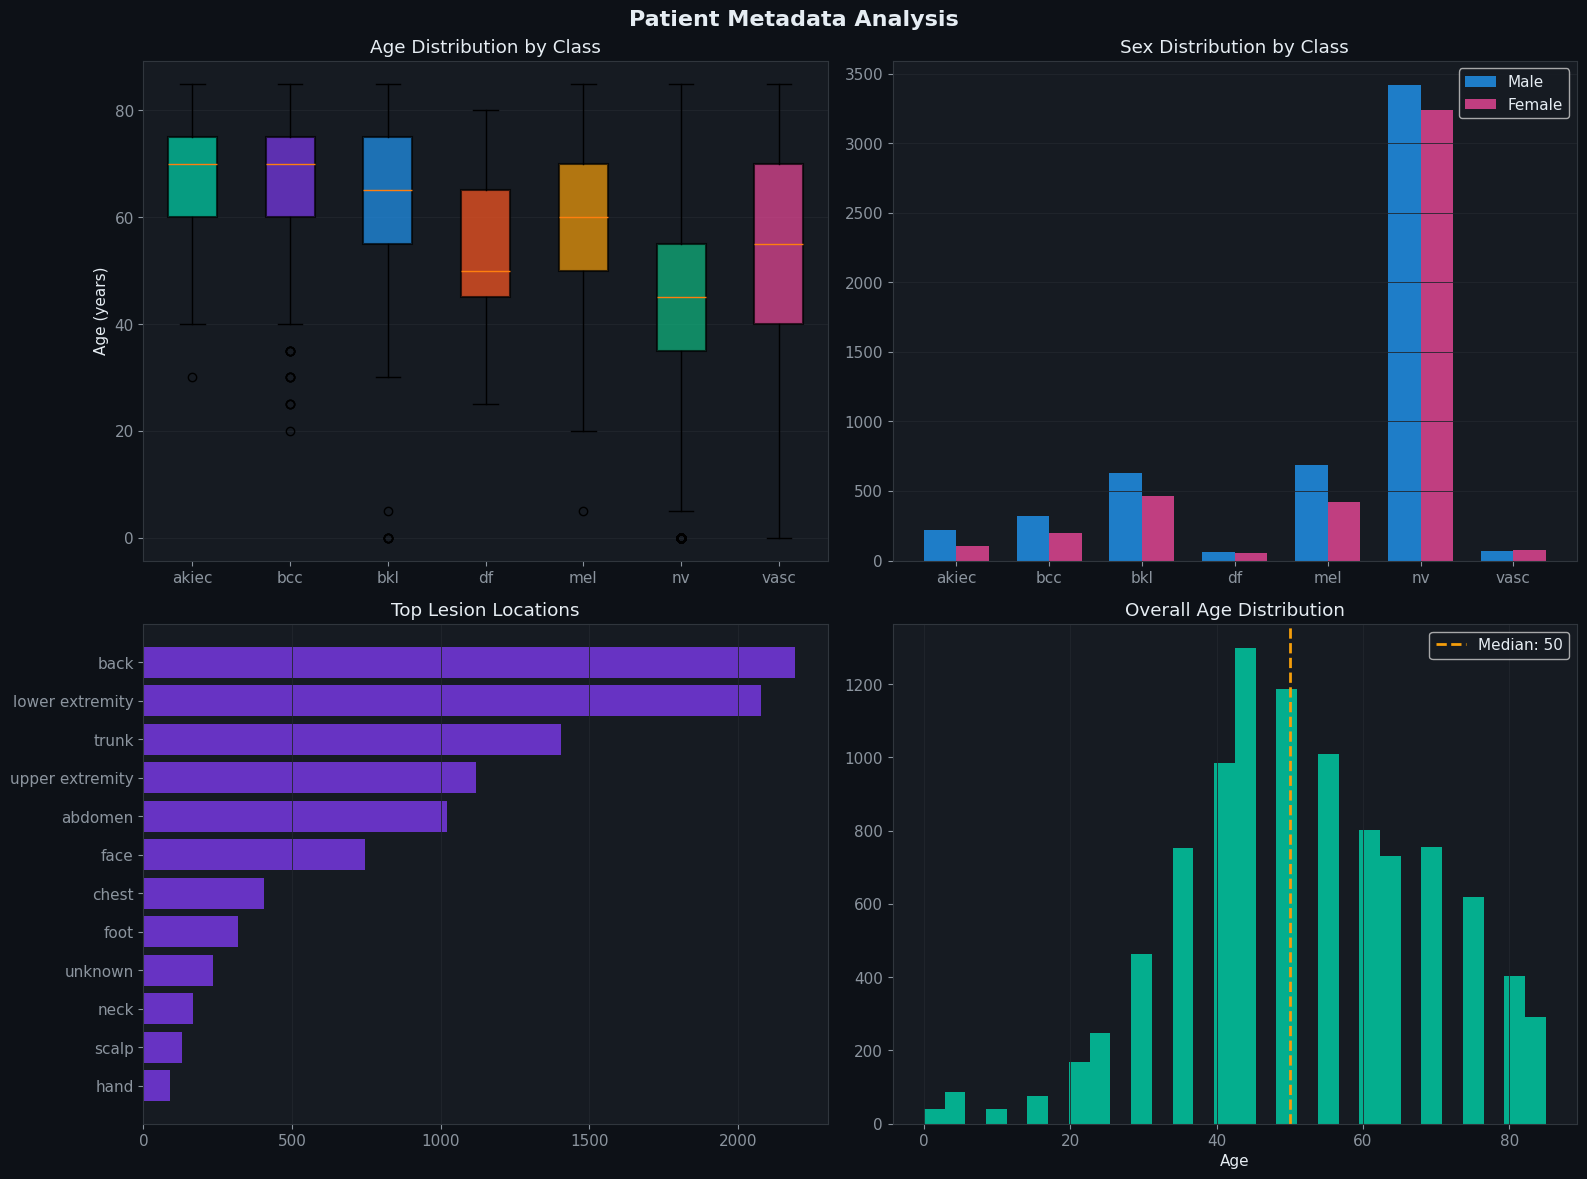

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Patient Metadata Analysis', fontsize=16, fontweight='bold')

# Age distribution
age_data = [df[df['dx']==c]['age'].dropna().values for c in CLASS_NAMES]
bp = axes[0][0].boxplot(age_data, labels=CLASS_NAMES, patch_artist=True,
                         boxprops=dict(linewidth=1.5))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0][0].set_title('Age Distribution by Class')
axes[0][0].set_ylabel('Age (years)')
axes[0][0].grid(axis='y')

# Sex distribution per class
sex_df = df.groupby(['dx','sex']).size().unstack(fill_value=0)
sex_df = sex_df.reindex(CLASS_NAMES)
x = np.arange(len(CLASS_NAMES))
w = 0.35
if 'male' in sex_df.columns:
    axes[0][1].bar(x - w/2, sex_df['male'], w, label='Male', color='#2196F3', alpha=0.8)
if 'female' in sex_df.columns:
    axes[0][1].bar(x + w/2, sex_df['female'], w, label='Female', color='#ec4899', alpha=0.8)
axes[0][1].set_xticks(x); axes[0][1].set_xticklabels(CLASS_NAMES)
axes[0][1].set_title('Sex Distribution by Class')
axes[0][1].legend(); axes[0][1].grid(axis='y')

# Localization
loc_counts = df['localization'].value_counts().head(12)
axes[1][0].barh(loc_counts.index[::-1], loc_counts.values[::-1],
                color='#7c3aed', alpha=0.8)
axes[1][0].set_title('Top Lesion Locations')
axes[1][0].grid(axis='x')

# Age histogram overall
df['age'].dropna().hist(bins=30, ax=axes[1][1], color='#00d4aa', alpha=0.8, edgecolor='none')
axes[1][1].axvline(df['age'].median(), color='#f59e0b', lw=2, ls='--',
                   label=f'Median: {df["age"].median():.0f}')
axes[1][1].set_title('Overall Age Distribution')
axes[1][1].set_xlabel('Age'); axes[1][1].legend()
axes[1][1].grid(axis='y')

plt.tight_layout()
plt.savefig('../data/eda_metadata.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 5. Patient-Level Split & Data Leakage Check

Train:  6979 images  (5228 patients)
Val  :  1493 images  (1121 patients)
Test :  1543 images  (1121 patients)

✓ No data leakage detected!


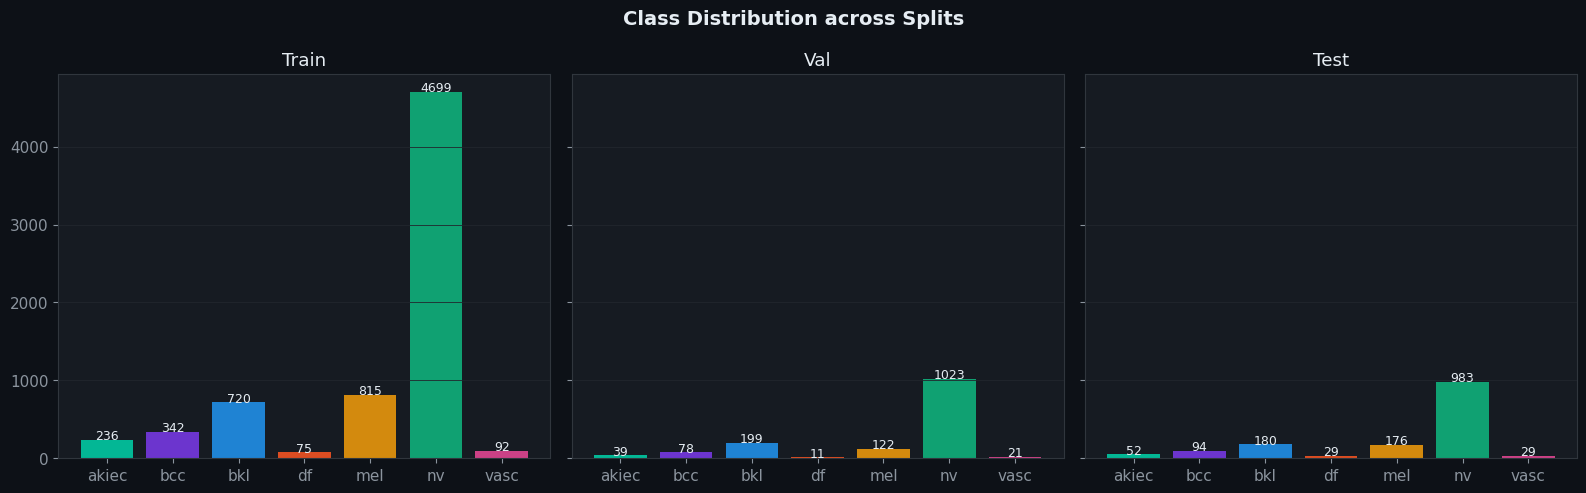

In [7]:
from sklearn.model_selection import train_test_split

unique_pts = df['lesion_id'].unique()
train_val_pts, test_pts = train_test_split(unique_pts, test_size=0.15, random_state=42)
train_pts, val_pts = train_test_split(train_val_pts, test_size=0.15/0.85, random_state=42)

train_df = df[df['lesion_id'].isin(train_pts)]
val_df   = df[df['lesion_id'].isin(val_pts)]
test_df  = df[df['lesion_id'].isin(test_pts)]

print(f'Train: {len(train_df):>5} images  ({train_df["lesion_id"].nunique()} patients)')
print(f'Val  : {len(val_df):>5} images  ({val_df["lesion_id"].nunique()} patients)')
print(f'Test : {len(test_df):>5} images  ({test_df["lesion_id"].nunique()} patients)')

# Verify no leakage
assert len(set(train_pts) & set(val_pts))  == 0, 'LEAKAGE: train-val'
assert len(set(train_pts) & set(test_pts)) == 0, 'LEAKAGE: train-test'
assert len(set(val_pts)   & set(test_pts)) == 0, 'LEAKAGE: val-test'
print('\n✓ No data leakage detected!')

# Split class distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Class Distribution across Splits', fontsize=14, fontweight='bold')
for ax, (split_df, title) in zip(axes, [(train_df,'Train'),(val_df,'Val'),(test_df,'Test')]):
    cnt = [split_df[split_df['dx']==c].shape[0] for c in CLASS_NAMES]
    ax.bar(CLASS_NAMES, cnt, color=COLORS, alpha=0.85)
    ax.set_title(title); ax.grid(axis='y')
    for i, c in enumerate(cnt):
        ax.text(i, c+2, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/eda_split_distribution.png', dpi=130, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 6. Class Weights Calculation

In [8]:
counts_arr = np.array([train_df[train_df['dx']==c].shape[0] for c in CLASS_NAMES])
weights = 1.0 / np.maximum(counts_arr, 1)
weights = weights / weights.sum() * len(CLASS_NAMES)

print('Class Weights for Loss Function:')
print(f'  {"-"*35}')
for cls, w, cnt in zip(CLASS_NAMES, weights, counts_arr):
    bar = '█' * int(w * 5)
    print(f'  {cls:>6}: weight={w:.3f}  count={cnt:>5}  {bar}')

print('\n→ Sao chép weights này vào training script nếu cần.')
print(f'\nweights = {[round(w,4) for w in weights]}')

Class Weights for Loss Function:
  -----------------------------------
   akiec: weight=0.867  count=  236  ████
     bcc: weight=0.599  count=  342  ██
     bkl: weight=0.284  count=  720  █
      df: weight=2.730  count=   75  █████████████
     mel: weight=0.251  count=  815  █
      nv: weight=0.044  count= 4699  
    vasc: weight=2.225  count=   92  ███████████

→ Sao chép weights này vào training script nếu cần.

weights = [np.float64(0.8675), np.float64(0.5986), np.float64(0.2843), np.float64(2.7296), np.float64(0.2512), np.float64(0.0436), np.float64(2.2252)]


## 7. Image Size Analysis

In [9]:
# Sample 100 images để kiểm tra kích thước
sample_ids = df['image_id'].sample(min(100, len(df)), random_state=42)
widths, heights = [], []

for img_id in sample_ids:
    p = find_image(img_id, DATA_DIR)
    if p:
        w, h = Image.open(p).size
        widths.append(w); heights.append(h)

print(f'Width  — mean: {np.mean(widths):.0f}  std: {np.std(widths):.0f}  range: [{min(widths)}, {max(widths)}]')
print(f'Height — mean: {np.mean(heights):.0f}  std: {np.std(heights):.0f}  range: [{min(heights)}, {max(heights)}]')
print(f'\nAll images will be resized to 224×224 for EfficientNet-B3')

Width  — mean: 600  std: 0  range: [600, 600]
Height — mean: 450  std: 0  range: [450, 450]

All images will be resized to 224×224 for EfficientNet-B3


## ✅ EDA Summary

| Insight | Kết quả |
|---------|----------|
| Tổng ảnh | 10,015 |
| Số class | 7 |
| Class phổ biến nhất | `nv` (~67%) |
| Class hiếm nhất | `df` / `vasc` (~1%) |
| Imbalance ratio | ~58x |
| Kích thước ảnh gốc | 600×450 px |
| Input model | 224×224 px |
| Giải pháp imbalance | WeightedRandomSampler + Class Weights |